In [1]:
import os
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

from scipy.ndimage import gaussian_filter
from skimage import measure
import itertools
from sklearn.cluster import KMeans
from pathlib import Path

from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED,
)

from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_splitted_channels_nir,
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/7 AddMultiSpectral/Target_FoV_recalibration/"
)

# Homographic matrix
#-------------------
H_matrix_path = os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/homographic_matrix/")

# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/AddMultiSpectral/Spatial_FoV_recalibration/")

# Data management

## Metadata of the sensors

### CRED2Lite

In [3]:
metadata_CRED=pd.read_csv(f'{data_path}/CRED/metadata.csv', encoding='unicode_escape', sep=',')
tim_python_CRED=np.asarray(metadata_CRED['t(s)'])
id_im_CRED=np.asarray(metadata_CRED['ImageUniqueID'])

In [4]:
threshold = 5

time_diffs = np.diff(tim_python_CRED)
group_indices = np.where(time_diffs > threshold)[0] + 1
group_indices = np.concatenate(([0], group_indices, [len(tim_python_CRED)]))

info_CRED = []
for i in range(len(group_indices) - 1):
    start_idx = group_indices[i]
    end_idx = group_indices[i + 1] - 1
    group_times = tim_python_CRED[start_idx:end_idx + 1]
    info_CRED.append({
        'cordon': i + 1,
        'start_idx': start_idx,
        'end_idx': end_idx,
        'times': group_times,
        'mean period':np.mean(np.diff(group_times)),
        'duration':group_times[-1]-group_times[0],
        'nb frame':len(group_times)
    })

### XIMEA

In [5]:
# sub_width = SUB_WIDTH_XIQ
# sub_length = SUB_LENGTH_XIQ
metadata_NIR=pd.read_csv(f'{data_path}/XIQ/metadata.csv', encoding='unicode_escape', sep=',')
tim_python_NIR=np.asarray(metadata_NIR['t(s)'])
tim_XIMEA_NIR=np.asarray(metadata_NIR['XimeaSec']) + np.asarray(metadata_NIR['XimeaUSec'])*1e-6 
id_im_NIR=np.asarray(metadata_NIR['ImageUniqueID'])

In [6]:
time_diffs = np.diff(tim_python_NIR)
group_indices = np.where(time_diffs > threshold)[0] + 1
group_indices = np.concatenate(([0], group_indices, [len(tim_python_NIR)]))

info_XIMEA = []
for i in range(len(group_indices) - 1):
    start_idx = group_indices[i]
    end_idx = group_indices[i + 1] - 1
    group_times = tim_python_NIR[start_idx:end_idx + 1]
    info_XIMEA.append({
        'cordon': i + 1,
        'start_idx': start_idx,
        'end_idx': end_idx,
        'times': group_times,
        'mean period':np.mean(np.diff(group_times)),
        'duration':group_times[-1]-group_times[0],
        'nb frame':len(group_times)
    })

## Time synchronization

In [7]:
CORDON=1
PERC=0.6
data_CRED=info_CRED[CORDON-1]
data_XIMEA=info_XIMEA[CORDON-1]

ref_time=min(data_CRED['times'][0], data_XIMEA['times'][0])
local_time_CRED=data_CRED['times']-ref_time
local_time_XIMEA=data_XIMEA['times']-ref_time

# Lower frequency: XIMEA is processed first
relative_id_XIMEA=np.abs(local_time_XIMEA - PERC*data_XIMEA['duration']).argmin()
relative_time_XIMEA=local_time_XIMEA[relative_id_XIMEA]
absolute_id_XIMEA=relative_id_XIMEA+data_XIMEA['start_idx']

# Then the neasrt CRED image is taken
relative_id_CRED=np.abs(local_time_CRED - relative_time_XIMEA).argmin()
relative_time_CRED=local_time_CRED[relative_id_CRED]
absolute_id_CRED=relative_id_CRED + data_CRED['start_idx']


/tmp/ipykernel_17001/3240293066.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', '', 'CRED','','','', 'NIR', ''])


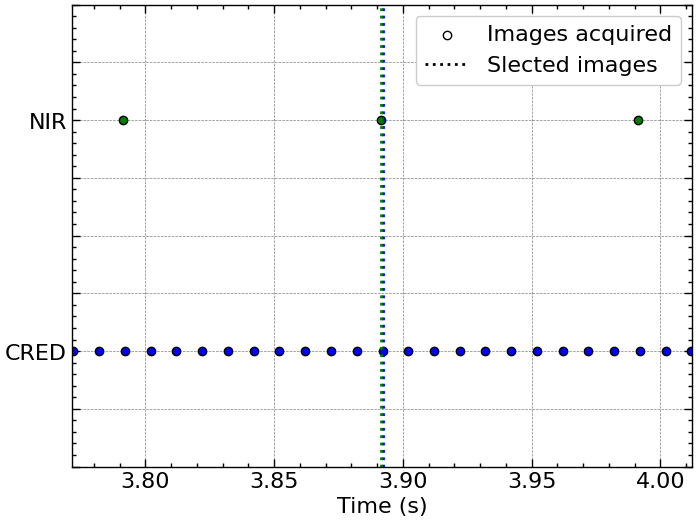

In [8]:
fig, ax = plt.subplots()

img_prise=[relative_time_CRED, relative_time_XIMEA]
extr=0.12

ax.vlines(
    img_prise,
    ymin=-0.5,
    ymax=1.5,
    color=['b', 'g'],
    linestyles='dotted'
    )
ax.scatter([0],[0], facecolor='white', edgecolor='black', label="Images acquired")
ax.plot([0,0],[0,0], c='black', label="Slected images", linestyle='dotted')


ax.scatter(local_time_CRED, np.ones(len(local_time_CRED))*0, facecolor='blue', edgecolor='black')
ax.scatter(local_time_XIMEA, np.ones(len(local_time_XIMEA))*1, facecolor='green', edgecolor='black')

ax.set_yticklabels(['', '', 'CRED','','','', 'NIR', ''])
ax.set_ylim(-0.5, 1.5)
ax.set_xlim(min(img_prise)-extr, max(img_prise)+extr)
ax.legend()
ax.set_xlabel('Time (s)')
plt.show()

## Images selected

### CRED2Lite

In [9]:
path_frame_chosen_CRED = os.path.join(
    f"{data_path}/CRED", 
    f'{id_im_CRED[absolute_id_CRED]:06d}_{tim_python_CRED[absolute_id_CRED]:.3f}.npy'
)
im_CRED=load_cred_array(path_frame_chosen_CRED)

### Ximea

In [10]:
XIMEA_frame_path = os.path.join(
    f"{data_path}/XIQ",
    f"{id_im_NIR[absolute_id_XIMEA]:06d}_{tim_python_NIR[absolute_id_XIMEA]:.3f}.npy",
)
im_XiQ_NIR=load_splitted_channels_nir(XIMEA_frame_path)

### Results

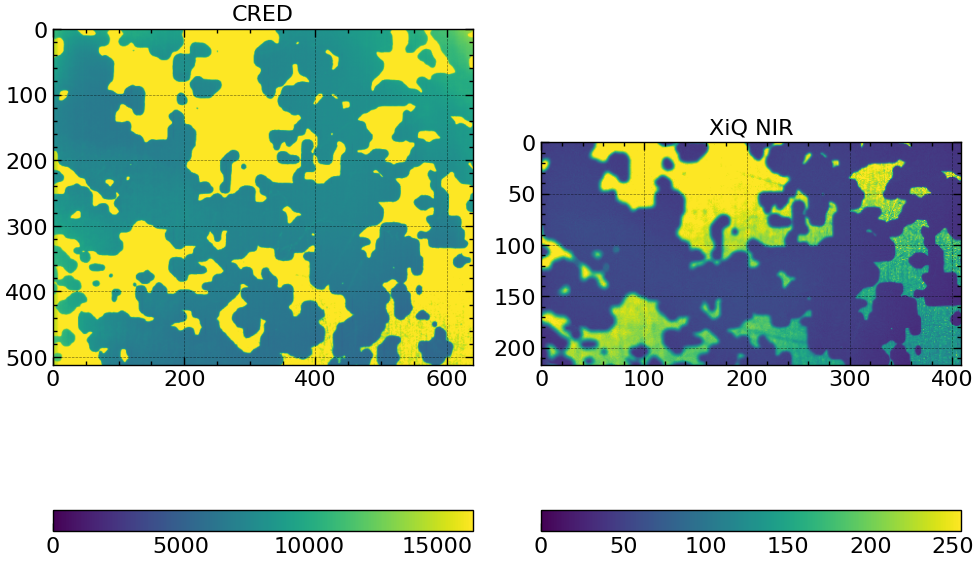

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
cmp = 'viridis'

im1 = axes[0].imshow(im_CRED, cmap=cmp, vmin=0, vmax=2**14)
axes[0].set_title('CRED')
fig.colorbar(im1, ax=axes[0], orientation="horizontal")

im2 = axes[1].imshow(im_XiQ_NIR[8], cmap=cmp, vmin=0, vmax=255)
axes[1].set_title(f'XiQ NIR')
fig.colorbar(im2, ax=axes[1], orientation="horizontal")

plt.tight_layout()
plt.show()


# Spatial FoV recalibration
Calculating the homographic transformation matrix

In [12]:
def get_H(img_C, img_XIQ, canal, see_match=False, see_result=False, savefig=False):
    img_ref=cv2.normalize(img_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_disto=cv2.normalize(img_XIQ, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    sift = cv2.SIFT_create()
    # Détecter les points d'intérêt et calculer les descripteurs
    keypoints1, descriptors1 = sift.detectAndCompute(img_disto, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img_ref, None)

    index_params = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Trouver les correspondances entre les descripteurs
    matches = flann.knnMatch(descriptors1, descriptors2, k=2)

    # Appliquer le ratio test de Lowe pour filtrer les bonnes correspondances
    good_matches = []
    for m, n in matches:
        if m.distance < 0.5 * n.distance:
            good_matches.append(m)

    if see_match:
        # Dessiner les correspondances
        result_image = cv2.drawMatches(img_disto, keypoints1, img_ref, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(result_image, cmap='gray')
        ax.axes.get_xaxis().set_ticks([])
        ax.axes.get_yaxis().set_ticks([])
        plt.grid(False)
        plt.tight_layout()
        if savefig:
            plt.savefig(f"./{saving_path}/match_transformation/match_ch{canal}.png")
            plt.close(fig)
        else:
            plt.show()


    # Extraire les points d'intérêt correspondants
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 2)
    dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 2)

    # Calculer l'homographie
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Aligner l'image 1 sur l'image 2
    aligned_image = cv2.warpPerspective(img_disto, H, (COLUMNS_CRED, LINES_CRED))

    if see_result:
        # Afficher les images
        fig, axes = plt.subplots(1, 2, figsize=(12, 8))
        image=[img_disto, aligned_image]
        for i, ax in enumerate(axes):
            ax.imshow(image[i], cmap='viridis', vmin=0, vmax=255)
            ax.tick_params(labelsize=12) 
            # ax.axes.get_xaxis().set_ticks([])
            # ax.axes.get_yaxis().set_ticks([])
        plt.grid(False)
        plt.tight_layout()
        if savefig:
            plt.savefig(f"./{saving_path}/transformation/match_ch{canal}.png")
            plt.close(fig)
        else:
            plt.show()


    return H


### Create Homographic Matrix

In [13]:
save_matrix = False

if save_matrix:
    matrice_H={}
    for ch in range(24):
        sub_im_XiQ_NIR=im_XiQ_NIR[ch]
        H = get_H(
            img_C=im_CRED, 
            img_XIQ=im_XiQ_NIR[ch], 
            canal=ch+1,
            see_match=True, 
            see_result=True, 
            savefig=True
        )

    with open('H_matrix.pkl', 'wb') as f:
        pickle.dump(matrice_H, f)

### Load Homographic Matrix

In [14]:
with open(f'{H_matrix_path}/H_matrix.pkl', 'rb') as f:
    matrice_H = pickle.load(f)

### Apply homographic matrix

In [15]:
chanel=8
XIQ_raw=im_XiQ_NIR[chanel]
H_i=matrice_H[chanel]
XIQ_rescaled=cv2.warpPerspective(XIQ_raw, H_i, (COLUMNS_CRED, LINES_CRED))
im_CRED_bin = im_CRED > 14000
aligned_image_bin = XIQ_rescaled > 100
mask_no_data=XIQ_rescaled==0

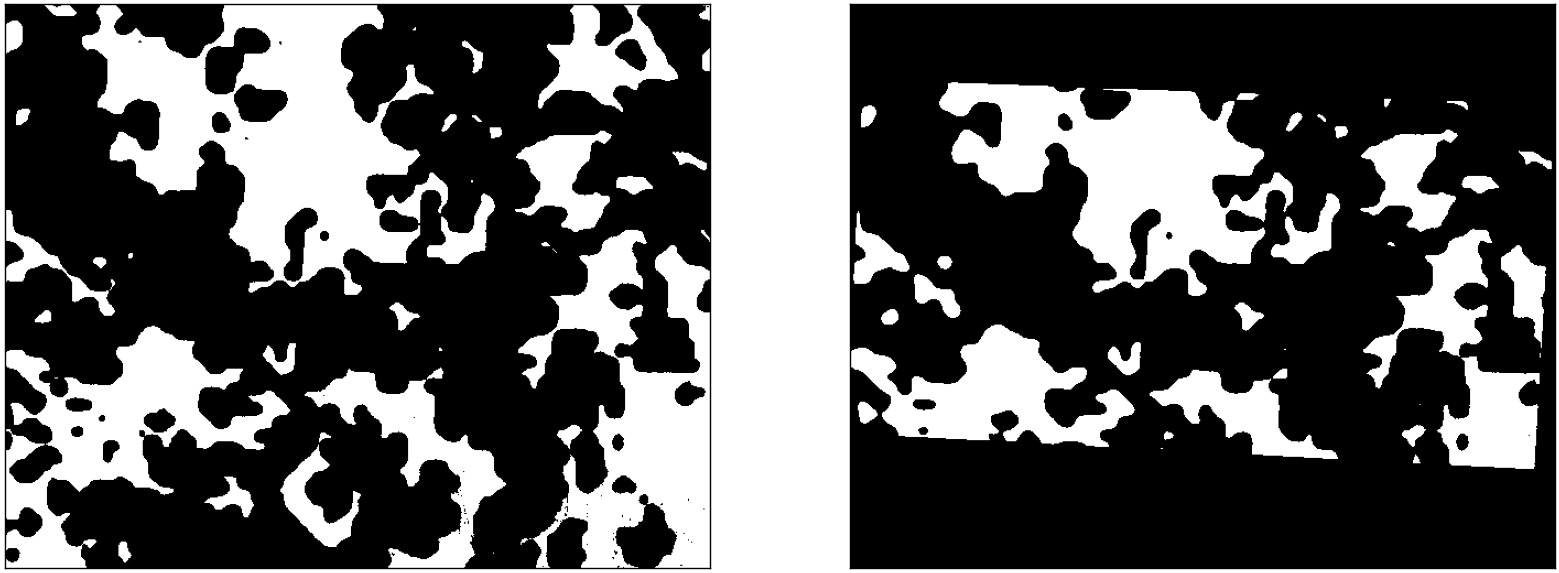

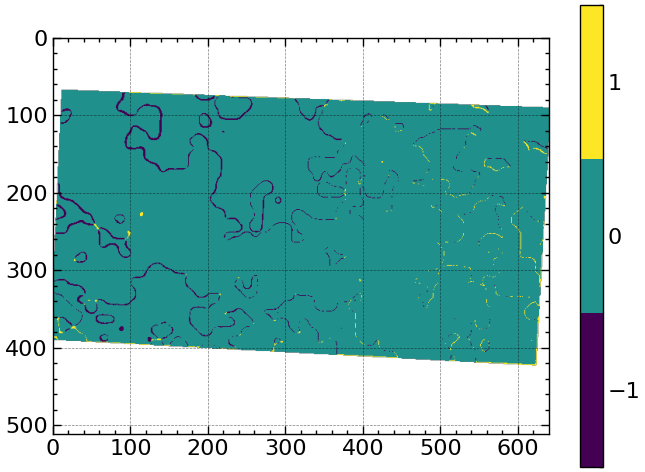

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
axes[0].axes.get_xaxis().set_ticks([])
axes[0].axes.get_yaxis().set_ticks([])
axes[0].grid(False)
axes[0].imshow(im_CRED_bin, cmap='gray')

axes[1].axes.get_xaxis().set_ticks([])
axes[1].axes.get_yaxis().set_ticks([])
axes[1].grid(False)
plt.imshow(aligned_image_bin, cmap='gray')
plt.show()

import matplotlib.colors as mcolors
diff_arr=im_CRED_bin.astype(float)-aligned_image_bin.astype(float)
diff_arr[mask_no_data]=np.nan
fig, ax = plt.subplots()

bounds=[-1.5, -0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, ncolors=len(bounds)-1)
cmap = plt.get_cmap('viridis', len(bounds)-1)
cax=ax.imshow(diff_arr, cmap=cmap, norm=norm)
cbar = fig.colorbar(cax, ticks=[-1, 0, 1])
plt.show()